# Laboratorio: eliminación de anomalías de la imagen
**Anomalía:** ruido impulsivo (sal y pimienta) · **Método:** detector contextual con vecinos fiables y restauración ponderada (implementación propia)

## 1. Integrantes del grupo

| Nombre y apellidos | Correo |
|---|---|
| Edna Mayerly Álvarez Celis | ednalvarez@gmail.com |
| Manuel Alejandro Murcia Sánchez | mmurcia57@gmail.com |
| Mateo Torres Arredondo | mateotorres2409@gmail.com |

## 2. Descripción del problema

El **ruido impulsivo** (sal y pimienta) aparece por fallos de sensor, píxeles muertos o errores de transmisión: una fracción aleatoria de píxeles pasa a valores extremos (0 o 255) y el resto conserva la información original. El problema tiene dos partes:

1. **Detección:** que un píxel sea extremo no basta para decir que es ruido. Una camisa blanca o una sombra negra contienen píxeles saturados legítimos. Un umbral global los borraría.
2. **Restauración:** un filtro de mediana aplicado a toda la imagen elimina el ruido, pero también modifica los píxeles sanos (cerca del 90 %) y suaviza bordes y texturas.

Objetivo: detectar **solo** los impulsos usando el contexto local y sustituirlos **solo a ellos**, con un algoritmo y unos parámetros únicos que sirvan para cualquier imagen (gris o color) con esta anomalía.

## 3. Imágenes de ejemplo con la anomalía

Se usan tres fotografías reales de contenido muy distinto, sacadas de `skimage.data` (dominio público/CC0): *astronaut* (color, con cuello y casco negros saturados), *coffee* (color, con texturas y reflejos) y *camera* (gris, con abrigo negro saturado). Se reescalan a 256×256 y se contaminan con el **mismo** proceso (`scripts/generate_data.py`): el 10 % de los píxeles pasa a 0 o a 255 con la misma probabilidad. Conservamos la imagen limpia y la máscara real **solo para evaluar**: el algoritmo nunca las ve.

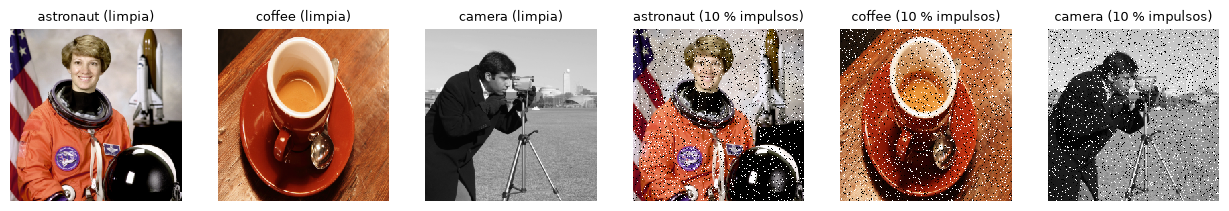

In [1]:
from pathlib import Path
import sys
import numpy as np
from PIL import Image, ImageFilter

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import anomaly_removal as ar
from src.metrics import detection_metrics, restoration_metrics
from src.visualization import show_row, show_decisions, show_results_grid, markdown_table
from scripts.generate_data import add_impulses

NAMES = {1: 'astronaut', 2: 'coffee', 3: 'camera'}
def load(index, kind):
    return np.asarray(Image.open(ROOT / f'data/{kind}_{index}/{kind}_{index}.png'))

data = {i: dict(clean=load(i, 'original'), corrupted=load(i, 'corrupted'), truth=load(i, 'mask') > 0) for i in NAMES}
show_row([data[i]['clean'] for i in NAMES] + [data[i]['corrupted'] for i in NAMES],
         [f'{NAMES[i]} (limpia)' for i in NAMES] + [f'{NAMES[i]} (10 % impulsos)' for i in NAMES], size=2.1)

## 4. Solución propuesta

**Idea.** Un impulso es un píxel saturado que **no encaja con sus vecinos sanos**. Por eso el contexto de cada píxel se calcula **solo con vecinos fiables** (no saturados): si se incluyeran los demás impulsos de la ventana, el contexto quedaría contaminado, que es lo que le pasa a la mediana clásica con ruido denso.

**Algoritmo** (por canal; implementado a mano en `src/anomaly_removal.py`, sin filtros de librería):

1. **Candidatos.** Píxeles con valor entre 0 y 10 o entre 245 y 255. Todo impulso es candidato, pero no todo candidato es impulso.
2. **Decisión contextual** para cada candidato:
   - *Ventana adaptativa:* empieza en 3×3 y crece hasta 9×9 hasta reunir al menos 4 vecinos fiables (la idea es la del filtro de mediana adaptativo).
   - *Test de región saturada:* si tiene al menos 3 vecinos con su misma saturación en 3×3 **y** al menos 8 en 5×5, forma parte de un objeto saturado real y se conserva. La esquina de un objeto ya cumple ambas condiciones. Con ruido de densidad *d*, cada vecino coincide solo con probabilidad *d*/2, así que reunir ambas por azar es improbable.
   - *Test de envolvente:* es impulso si su valor queda fuera de [mín − 20, máx + 20] de los vecinos fiables. Así un píxel muy oscuro junto a vecinos oscuros no se marca.
3. **Restauración** solo de los píxeles marcados: media de los vecinos **no marcados**, con pesos espaciales (gaussianos) multiplicados por pesos de rango (1 / (1 + |v − mediana|)).

**Alternativas descartadas.** Un umbral global borra objetos saturados reales. La mediana de librería no es una contribución propia, modifica todos los píxeles y se usa aquí **solo como referencia**. Una versión previa de este trabajo usaba un margen proporcional a la MAD (identificador de Hampel): en zonas texturizadas la MAD crecía tanto que se escapaba más del 30 % de los impulsos, y la sustituimos por la envolvente de vecinos fiables.

**Parámetros fijos para todas las imágenes:**

In [2]:
{k: getattr(ar, k) for k in ['SATURATION_MARGIN', 'MIN_RADIUS', 'MAX_RADIUS', 'MIN_SUPPORT',
                               'REGION_NEIGHBOURS_3X3', 'REGION_NEIGHBOURS_5X5', 'ENVELOPE_TOLERANCE']}

{'SATURATION_MARGIN': 10,
 'MIN_RADIUS': 1,
 'MAX_RADIUS': 4,
 'MIN_SUPPORT': 4,
 'REGION_NEIGHBOURS_3X3': 3,
 'REGION_NEIGHBOURS_5X5': 8,
 'ENVELOPE_TOLERANCE': 20.0}

## 5. Ejecución paso a paso del algoritmo

### 5.1 Etapas 1 y 2 sobre *astronaut* (canal rojo)
`analyze_channel` devuelve los mapas intermedios. Ampliamos el cuello negro del traje, donde conviven impulsos y una región saturada real, para ver las tres decisiones posibles.

Candidatos: 15704 de 65536 píxeles -> {'impulso': 5663, 'region_saturada': 9547, 'dentro_envolvente': 494}


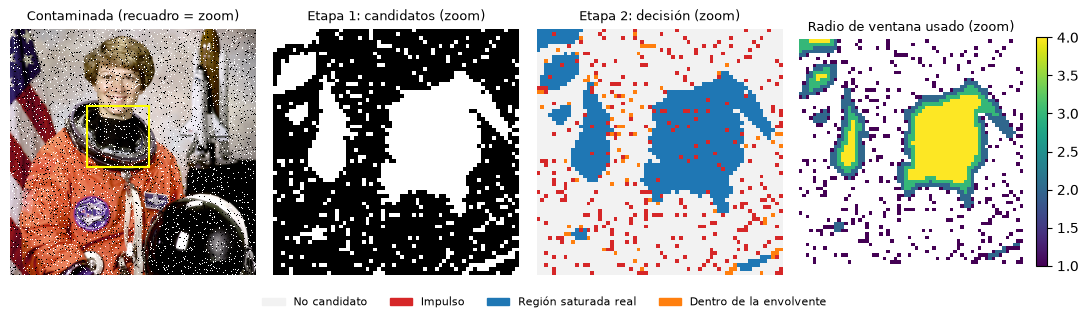

In [3]:
channel = data[1]['corrupted'][:, :, 0].astype(np.float32)
details = ar.analyze_channel(channel)
decisions = {name: int((details.decision == code).sum()) for name, code in
             [('impulso', ar.IMPULSE), ('region_saturada', ar.SATURATED_REGION), ('dentro_envolvente', ar.INSIDE_ENVELOPE)]}
print(f'Candidatos: {details.candidates.sum()} de {channel.size} píxeles ->', decisions)
show_decisions(data[1]['corrupted'], details, crop=(80, 144, 80, 144))

**Lectura.** En la etapa 1 aparecen candidatos dispersos (impulsos) y bloques compactos (el cuello negro, saturado de verdad). La etapa 2 separa ambos casos: los bloques se conservan como *región saturada real* (azul) y los puntos aislados se marcan como *impulso* (rojo). Los candidatos naranjas son píxeles casi negros junto a vecinos oscuros: su valor es compatible con el entorno y no se tocan. El radio de la ventana crece (amarillo) solo donde los vecinos fiables escasean, en el interior del traje y en grupos de impulsos.

### 5.2 Etapa 3: restauración del canal
Comparamos solo los píxeles marcados con su valor original. El resto no cambia por construcción.

In [4]:
restored_channel = ar.restore_impulses(channel, details.mask)
clean_channel = data[1]['clean'][:, :, 0].astype(float)
print('Píxeles modificados:', int((restored_channel != channel).sum()), '| fuera de la máscara:',
      int((restored_channel[~details.mask] != channel[~details.mask]).sum()))
print(f'Error medio en los píxeles restaurados: {np.abs(restored_channel[details.mask] - clean_channel[details.mask]).mean():.1f} niveles '
      f'(antes: {np.abs(channel[details.mask] - clean_channel[details.mask]).mean():.1f})')

Píxeles modificados: 5663 | fuera de la máscara: 0
Error medio en los píxeles restaurados: 4.7 niveles (antes: 144.4)


### 5.3 El mismo algoritmo en las tres imágenes
`remove_impulses` aplica las tres etapas a cada canal con los parámetros fijos. Cada fila muestra la detección, el resultado, el error frente a la imagen limpia (amplificado ×4) y un zoom central antes y después.

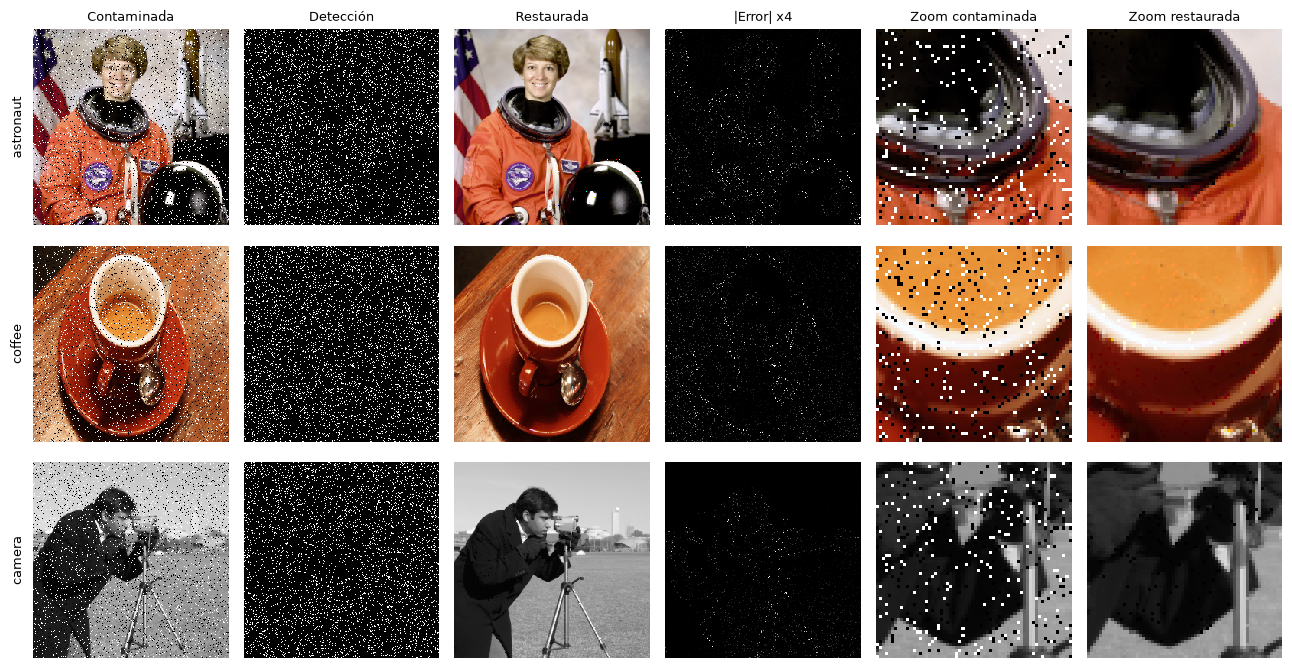

In [5]:
for i in NAMES:
    data[i]['restored'], data[i]['detected'] = ar.remove_impulses(data[i]['corrupted'])
    Image.fromarray(data[i]['restored']).save(ROOT / f'data/output/restored_{i}.png')
show_results_grid([(NAMES[i], data[i]['clean'], data[i]['corrupted'], data[i]['detected'], data[i]['restored']) for i in NAMES])

### 5.4 Validación cuantitativa
Detección frente a la máscara real (precisión, recall, F1) y restauración frente a la imagen limpia (PSNR en dB y SSIM). Referencias: no restaurar y la mediana 3×3 de Pillow, que **no** forma parte de la solución. La última columna da los impulsos no detectados y, entre paréntesis, cuántos de ellos tienen un error mayor que 40 niveles.

In [6]:
def median_baseline(image, size=3):
    return np.asarray(Image.fromarray(image).filter(ImageFilter.MedianFilter(size)))

rows = []
for i in NAMES:
    d, c = data[i], data[i]['clean']
    det = detection_metrics(d['detected'], d['truth'])
    noisy, med, ours = (restoration_metrics(c, x) for x in (d['corrupted'], median_baseline(d['corrupted']), d['restored']))
    missed = d['truth'] & ~d['detected']
    err = np.abs(c.astype(int) - d['corrupted'].astype(int)); err = err.max(axis=2) if err.ndim == 3 else err
    rows.append([NAMES[i], f"{det['precision']:.3f}", f"{det['recall']:.3f}", f"{det['f1']:.3f}", f"{noisy['psnr']:.1f}",
                 f"{med['psnr']:.1f} / {med['ssim']:.3f}", f"**{ours['psnr']:.1f} / {ours['ssim']:.3f}**",
                 f"{missed.sum()} ({(missed & (err > 40)).sum()})"])
markdown_table(['Imagen', 'Precisión', 'Recall', 'F1', 'PSNR sin restaurar', 'Mediana 3x3: PSNR / SSIM',
                'Propuesta: PSNR / SSIM', 'No detectados (error > 40)'], rows)

| Imagen | Precisión | Recall | F1 | PSNR sin restaurar | Mediana 3x3: PSNR / SSIM | Propuesta: PSNR / SSIM | No detectados (error > 40) |
|---|---|---|---|---|---|---|---|
| astronaut | 0.996 | 0.893 | 0.942 | 14.6 | 28.8 / 0.945 | **32.8 / 0.983** | 696 (48) |
| coffee | 0.997 | 0.981 | 0.989 | 14.7 | 29.3 / 0.883 | **35.3 / 0.971** | 125 (17) |
| camera | 0.999 | 0.929 | 0.963 | 14.8 | 30.2 / 0.895 | **37.0 / 0.978** | 460 (42) |

### 5.5 Generalización: densidad de ruido y imágenes limpias
Para comprobar que el método no está ajustado a un caso concreto, repetimos el experimento **sin cambiar nada** con densidades del 5 % al 30 % (nuevas semillas) y lo aplicamos a las imágenes **limpias**: un buen detector no debe tocarlas.

In [7]:
DENSITIES = (0.05, 0.10, 0.20, 0.30)
rows = []
for i in NAMES:
    clean = data[i]['clean']
    row = [NAMES[i], int(ar.remove_impulses(clean)[1].sum())]
    for density in DENSITIES:
        noisy, truth = add_impulses(clean, seed=100 + i, density=density)
        restored, mask = ar.remove_impulses(noisy)
        med = median_baseline(noisy, 3 if density < 0.15 else 5)
        row.append(f"{detection_metrics(mask, truth)['f1']:.3f} / **{restoration_metrics(clean, restored)['psnr']:.1f}** / "
                   f"{restoration_metrics(clean, med)['psnr']:.1f}")
    rows.append(row)
markdown_table(['Imagen', 'Píxeles tocados en la limpia'] + [f'{d:.0%}: F1 / PSNR prop. / PSNR mediana' for d in DENSITIES], rows)

| Imagen | Píxeles tocados en la limpia | 5%: F1 / PSNR prop. / PSNR mediana | 10%: F1 / PSNR prop. / PSNR mediana | 20%: F1 / PSNR prop. / PSNR mediana | 30%: F1 / PSNR prop. / PSNR mediana |
|---|---|---|---|---|---|
| astronaut | 18 | 0.943 / **35.7** / 30.0 | 0.944 / **33.1** / 28.7 | 0.944 / **28.8** / 24.7 | 0.937 / **24.7** / 23.9 |
| coffee | 17 | 0.986 / **38.6** / 30.0 | 0.988 / **35.6** / 29.2 | 0.988 / **32.0** / 26.3 | 0.983 / **26.4** / 25.8 |
| camera | 4 | 0.965 / **39.9** / 31.1 | 0.967 / **35.4** / 29.7 | 0.967 / **32.6** / 25.9 | 0.960 / **26.9** / 25.3 |

## 6. Conclusiones y limitaciones

- **Generaliza:** con los mismos parámetros funciona en color y en gris, en escenas con grandes zonas saturadas (cuello y casco negros, abrigo negro) y con densidades del 5 al 30 %. En las imágenes limpias modifica una fracción ínfima de píxeles (< 0,03 %).
- **Mejora la referencia:** al detectar antes de corregir, conserva intactos los píxeles sanos y supera en PSNR y SSIM a la mediana de librería en todos los casos probados (3 imágenes × 4 densidades). A diferencia de la mediana, no necesita elegir el tamaño de ventana según la densidad.
- **Los impulsos que se escapan apenas dañan la imagen:** son sobre todo sal sobre zonas ya casi blancas o pimienta sobre zonas casi negras, con error pequeño (ver 5.4).
- **Limitaciones:** (1) supone impulsos de valor extremo; con ruido impulsivo de valor aleatorio fallaría la etapa 1. (2) Líneas saturadas de 1 píxel de grosor no superan el test de región y se tratarían como ruido. (3) Por encima del 30 % de densidad los grupos aleatorios de impulsos empiezan a parecer regiones y la mediana ancha se vuelve competitiva. (4) Los bucles en Python son lentos para imágenes grandes; se podrían vectorizar.

## 7. Referencias

- Hwang, H. y Haddad, R. A. (1995). *Adaptive median filters: new algorithms and results*. IEEE Trans. Image Processing, 4(4), 499–502. → Idea de **ventana creciente**.
- Sun, T. y Neuvo, Y. (1994). *Detail-preserving median based filters in image processing*. Pattern Recognition Letters, 15(4), 341–347. → Idea de **filtro conmutado**: detectar antes de corregir.
- Tomasi, C. y Manduchi, R. (1998). *Bilateral filtering for gray and color images*. ICCV. → Idea de **pesos espaciales × pesos de rango** en la restauración.
- Gonzalez, R. C. y Woods, R. E. *Digital Image Processing* (4.ª ed.), cap. 5: modelos de ruido impulsivo.
- Imágenes: `skimage.data` (van der Walt et al., *scikit-image*, PeerJ 2014). Métrica SSIM: `skimage.metrics`.

El código es propio: no se ha copiado código de Internet. Las librerías se usan solo para leer y guardar imágenes, para las figuras, las métricas y la referencia de mediana. Las ideas anteriores se combinaron de forma original: contexto calculado solo con vecinos fiables, doble test de región saturada, envolvente local y restauración ponderada restringida a vecinos limpios.